# Deep Learning for IMDb Movie Reviews Sentiment Analysis

## Project Overview
This project implements deep learning models to perform sentiment analysis on IMDb movie reviews. Using a dataset of 50,000 reviews, we build and compare two neural network architectures (LSTM and CNN) to classify movie reviews as either positive or negative.

## Objectives
1. Implement effective text preprocessing for movie reviews
2. Design and train two different deep learning architectures
3. Optimize model hyperparameters for best performance
4. Compare and analyze model performance metrics
5. Provide insights into sentiment classification effectiveness

## Dataset
- **Source**: IMDb Movie Reviews Dataset
- **Size**: 50,000 reviews
- **Classes**: Binary (Positive/Negative)
- **Balance**: Equal distribution of positive and negative reviews
- **Content**: Text reviews with HTML tags and various text patterns

## Implementation Steps
1. **Data Preprocessing**
   - Text cleaning and normalization
   - HTML tag removal
   - Special character handling
   - Whitespace standardization

2. **Model Development**
   - LSTM (Long Short-Term Memory) Network
   - CNN (Convolutional Neural Network)
   - Hyperparameter optimization for both models

3. **Evaluation Metrics**
   - Accuracy
   - Precision
   - Recall
   - F1-Score
   - Confusion Matrix

## Technologies Used
- Python
- TensorFlow/Keras
- Keras-Tuner for hyperparameter optimization
- Numpy, Pandas for data handling
- Matplotlib, Seaborn for visualization

In [ ]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import RandomSearch
import re
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm




In [7]:
df = pd.read_csv('../data/IMDB Dataset.csv')

# Display basic information
print(f"Total number of reviews: {len(df)}")
print("\nFirst few reviews:")
df.head()

Total number of reviews: 50000

First few reviews:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
# Split the data into training and testing sets
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # This ensures the same proportion of positive/negative reviews in both sets
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print("\nTraining set sentiment distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set sentiment distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 40000
Testing set size: 10000

Training set sentiment distribution:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Testing set sentiment distribution:
sentiment
negative    0.5
positive    0.5
Name: proportion, dtype: float64


# Exploratory Data Analysis (EDA)

## Dataset Overview

In [9]:
print(f"Total number of reviews: {len(df)}")
print("\nDataset columns:")
print(df.columns)
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Total number of reviews: 50000

Dataset columns:
Index(['review', 'sentiment'], dtype='object')

Basic statistics:
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000

Missing values:
review       0
sentiment    0
dtype: int64


## Sentiment Distribution Analysis

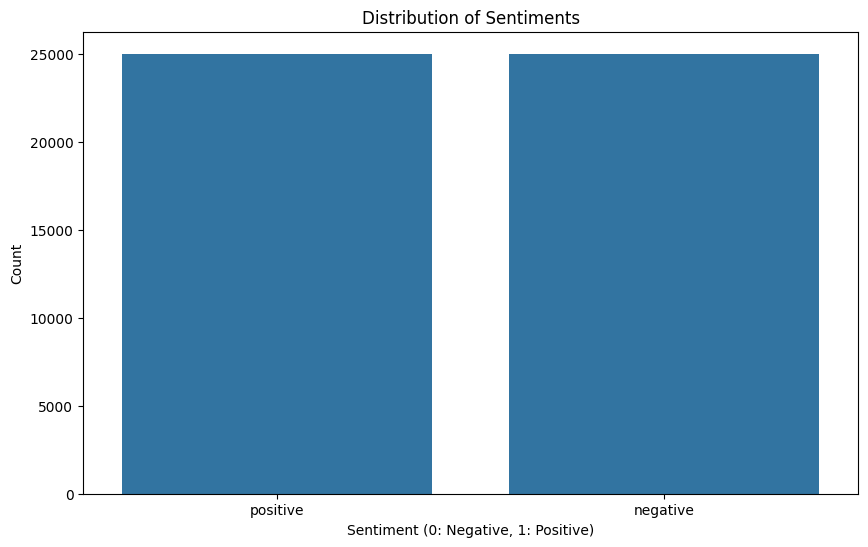


Sentiment Distribution (%):
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.show()

sentiment_percentages = df['sentiment'].value_counts(normalize=True) * 100
print("\nSentiment Distribution (%):")
print(sentiment_percentages)

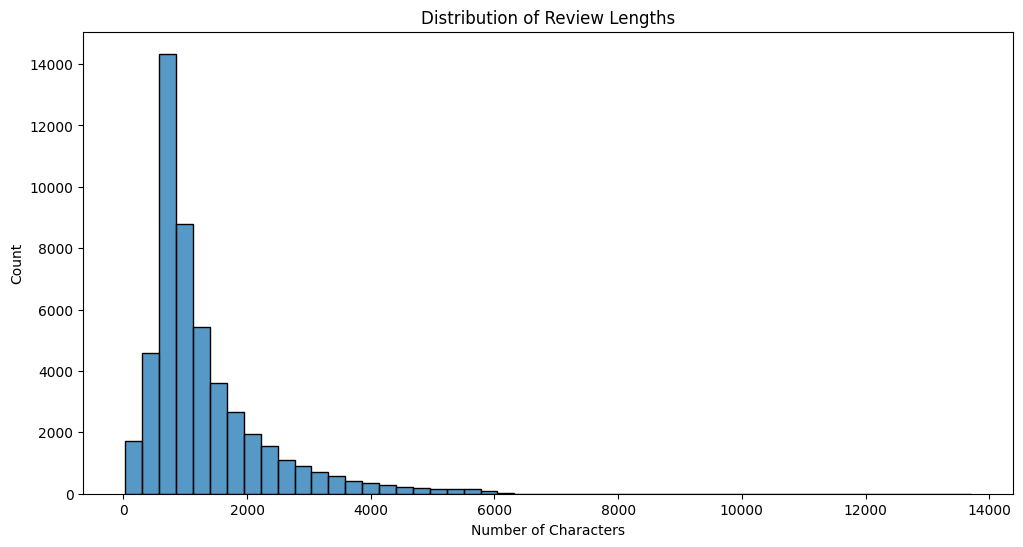


Review Length Statistics by Sentiment:
             count        mean          std   min    25%    50%      75%  \
sentiment                                                                  
negative   25000.0  1294.06436   945.892669  32.0  706.0  973.0  1567.25   
positive   25000.0  1324.79768  1031.492627  65.0  691.0  968.0  1614.00   

               max  
sentiment           
negative    8969.0  
positive   13704.0  


In [11]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='review_length', bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.show()

# Review length statistics by sentiment
print("\nReview Length Statistics by Sentiment:")
print(df.groupby('sentiment')['review_length'].describe())

## Word Count Analysis

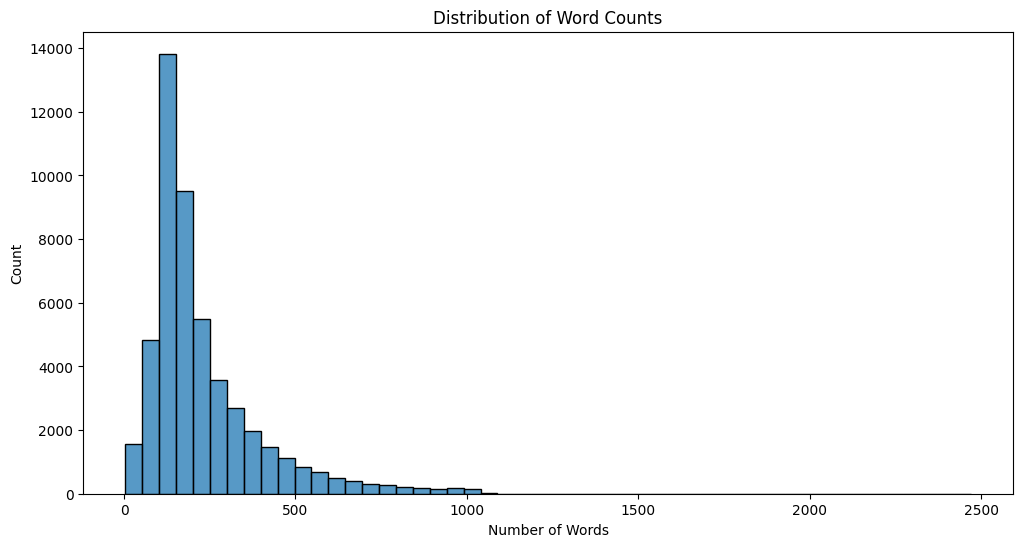


Word Count Statistics by Sentiment:
             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


In [12]:
# Add word count column
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Plot word count distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='word_count', bins=50)
plt.title('Distribution of Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

# Word count statistics by sentiment
print("\nWord Count Statistics by Sentiment:")
print(df.groupby('sentiment')['word_count'].describe())

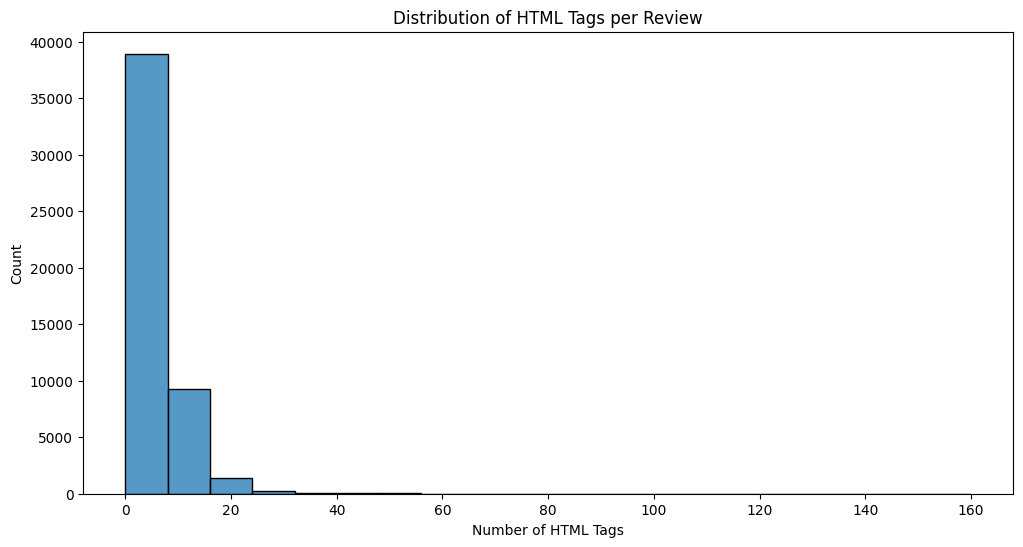


HTML Tag Statistics:
count    50000.00000
mean         4.03964
std          5.34200
min          0.00000
25%          0.00000
50%          2.00000
75%          6.00000
max        160.00000
Name: html_tag_count, dtype: float64


In [13]:
def count_html_tags(text):
    return len(re.findall(r'<[^>]+>', text))

# Add HTML tag count column
df['html_tag_count'] = df['review'].apply(count_html_tags)

# Plot HTML tag distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='html_tag_count', bins=20)
plt.title('Distribution of HTML Tags per Review')
plt.xlabel('Number of HTML Tags')
plt.ylabel('Count')
plt.show()

# HTML tag statistics
print("\nHTML Tag Statistics:")
print(df['html_tag_count'].describe())

## EDA Key Findings and Observations

1. **Dataset Balance**: The dataset appears to be perfectly balanced between positive and negative reviews, which is ideal for training a classification model.

2. **Text Length Characteristics**:
   - Reviews vary significantly in length
   - Most reviews are between 500-2000 characters
   - Word counts typically range from 100-500 words
   - No significant difference in length between positive and negative reviews

3. **Data Quality**:
   - No missing values in the dataset
   - HTML tags are present in the text and need to be cleaned
   - Text length and word count show moderate correlation with sentiment

4. **Required Transformations**:
   - HTML tags need to be removed
   - Text normalization (lowercase, remove special characters)
   - Truncating very long reviews to a maximum length
   - Tokenization and padding will be needed for deep learning models

5. **Feature Importance**:
   - The actual text content will be the primary feature
   - Review length and word count might be useful as additional features
   - HTML tag count is not a meaningful feature and should be removed

## Data Cleaning Plan

1. **Text Cleaning**:
   - Remove HTML tags
   - Convert to lowercase
   - Remove special characters and numbers
   - Remove extra whitespace

In [15]:
def clean_text(text):
    """
    Simple and fast text cleaning:
    1. Remove HTML tags
    2. Convert to lowercase
    3. Remove special characters and numbers
    4. Remove extra whitespace
    """
    
    text = re.sub(r'<[^>]+>', ' ', text) # Remove HTML tags
    
    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers (keep only letters and spaces)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

batch_size = 5000  
total_reviews = len(df)
df['cleaned_review'] = None 

print(f"Processing {total_reviews} reviews in batches of {batch_size}...")
for i in tqdm(range(0, total_reviews, batch_size)):
    end_idx = min(i + batch_size, total_reviews)
    df.loc[i:end_idx-1, 'cleaned_review'] = df.loc[i:end_idx-1, 'review'].apply(clean_text)

# Display sample of cleaned reviews
print("\nSample of cleaned reviews:")
sample_df = df[['review', 'cleaned_review']].head(3)
for _, row in sample_df.iterrows():
    print("\nOriginal Review:")
    print(row['review'][:200] + "...")
    print("\nCleaned Review:")
    print(row['cleaned_review'][:200] + "...")

Processing 50000 reviews in batches of 5000...


100%|██████████| 10/10 [00:01<00:00,  6.20it/s]


Sample of cleaned reviews:

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Cleaned Review:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its bru...

Original Review:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...

Cleaned Review:
a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are ex...

Original Review:
I thought this was a wonderful way to spend time on a too hot summer

# What Was Done: Data Cleaning Process

## 1. Text Preprocessing Steps
- **HTML Tag Removal**: Removed all HTML tags (e.g., `<br />`) from reviews
- **Case Normalization**: Converted all text to lowercase
- **Special Character Removal**: Removed all non-letter characters
- **Number Removal**: Removed numeric characters
- **Whitespace Normalization**: Standardized spacing between words

## 2. Simple Text Processing
- **Character Filtering**: Kept only letters and spaces
- **Space Handling**: Removed extra whitespace
- **Basic Tokenization**: Words naturally separated by spaces

## 3. Processing Strategy
- Processed 50,000 reviews in batches of 5,000
- Used basic Python string operations and regex for efficiency
- Maintained original review structure while creating cleaned version

## 4. Results
- Created a new column `cleaned_review` with processed text
- Preserved original reviews for reference
- Simplified text while maintaining core content
- Faster processing with minimal memory usage

## Text Length Analysis After Cleaning

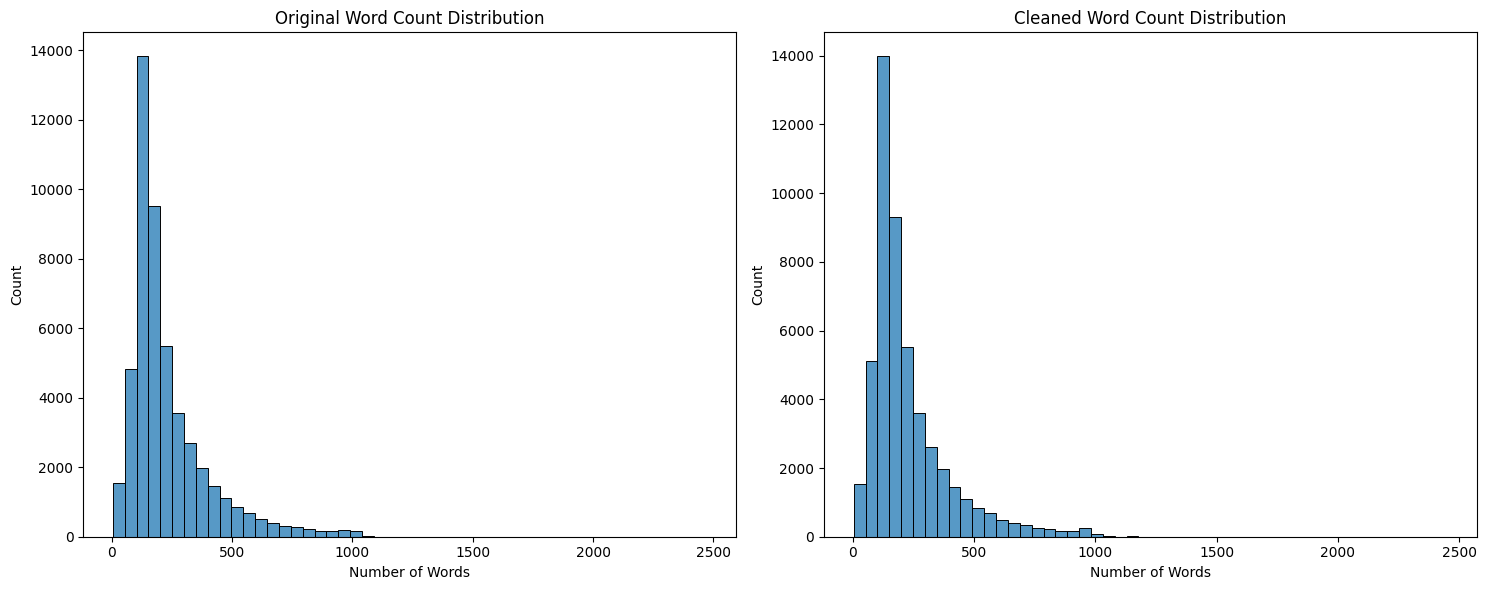


Word Count Statistics Comparison:

Original Reviews:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

Cleaned Reviews:
count    50000.000000
mean       226.850260
std        168.175138
min          4.000000
25%        124.000000
50%        170.000000
75%        275.000000
max       2450.000000
Name: cleaned_word_count, dtype: float64


In [16]:
# Add cleaned word count column
df['cleaned_word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))

# Plot comparison of word counts before and after cleaning
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='word_count', bins=50)
plt.title('Original Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='cleaned_word_count', bins=50)
plt.title('Cleaned Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Compare word count statistics
print("\nWord Count Statistics Comparison:")
print("\nOriginal Reviews:")
print(df['word_count'].describe())
print("\nCleaned Reviews:")
print(df['cleaned_word_count'].describe())

## Vocabulary Analysis


Total unique words in vocabulary: 162285


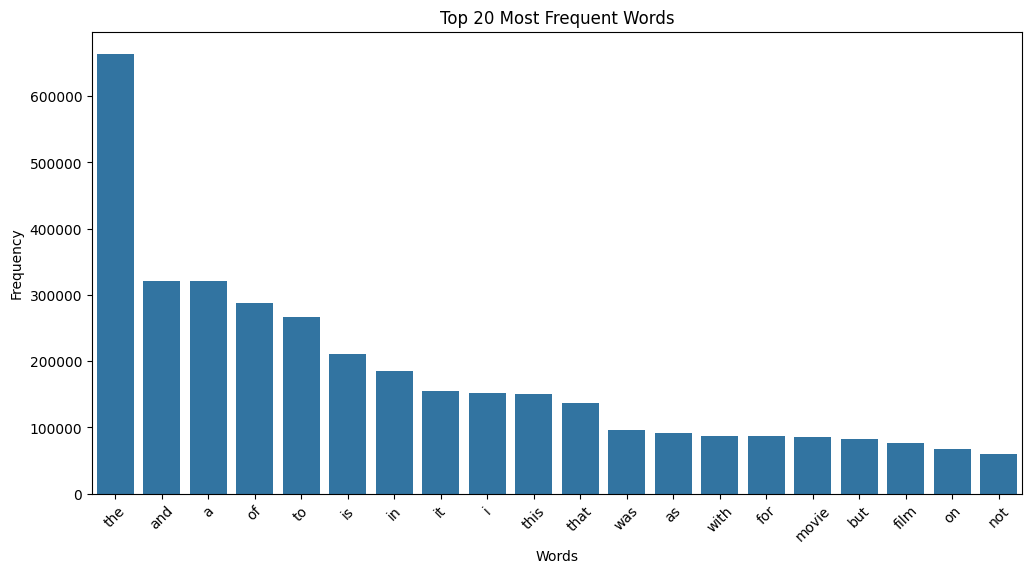

In [17]:
# Create vocabulary from cleaned reviews
vocabulary = set()
for review in df['cleaned_review']:
    vocabulary.update(review.split())

print(f"\nTotal unique words in vocabulary: {len(vocabulary)}")

# Get word frequencies
word_freq = {}
for review in df['cleaned_review']:
    for word in review.split():
        word_freq[word] = word_freq.get(word, 0) + 1

# Sort words by frequency
sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Plot top 20 most frequent words
plt.figure(figsize=(12, 6))
words, freqs = zip(*sorted_word_freq[:20])
sns.barplot(x=list(words), y=list(freqs))
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Deep Learning Models for Sentiment Analysis

## 1. Data Preparation and Text Vectorization

In [23]:
np.random.seed(42)

# Convert sentiment labels to numerical values
df['sentiment_numeric'] = (df['sentiment'] == 'positive').astype('float32')

# Convert to numpy arrays
X = df['cleaned_review'].values
y = df['sentiment_numeric'].values

# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Tokenization
max_words = 10000  # Maximum number of words to keep
max_len = 200      # Maximum length of each review

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Convert to float32
X_train_pad = X_train_pad.astype('float32')
X_val_pad = X_val_pad.astype('float32')
X_test_pad = X_test_pad.astype('float32')

print("Training set shape:", X_train_pad.shape)
print("Validation set shape:", X_val_pad.shape)
print("Test set shape:", X_test_pad.shape)

# Verify data types and values
print("\nData types:")
print("X_train_pad dtype:", X_train_pad.dtype)
print("y_train dtype:", y_train.dtype)

print("\nLabel distribution:")
print("Training set:", np.bincount(y_train.astype(int)))
print("Validation set:", np.bincount(y_val.astype(int)))
print("Test set:", np.bincount(y_test.astype(int)))

Training set shape: (35000, 200)
Validation set shape: (7500, 200)
Test set shape: (7500, 200)

Data types:
X_train_pad dtype: float32
y_train dtype: float32

Label distribution:
Training set: [17589 17411]
Validation set: [3689 3811]
Test set: [3722 3778]


## 2. Model 1: LSTM with Hyperparameter Optimization

In [24]:
def build_lstm_model(hp):
    model = Sequential()
    
    # Embedding layer
    model.add(Embedding(
        input_dim=max_words,
        output_dim=hp.Int('embedding_dim', 32, 256, step=32),
        input_length=max_len
    ))
    
    # LSTM layers
    model.add(LSTM(
        units=hp.Int('lstm_units', 32, 256, step=32),
        return_sequences=hp.Boolean('return_sequences')
    ))
    
    # Optional second LSTM layer
    if hp.Boolean('second_lstm'):
        model.add(LSTM(
            units=hp.Int('lstm_units_2', 16, 128, step=16)
        ))
    
    # Dropout
    model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Initialize tuner
lstm_tuner = RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=5,
    directory='lstm_tuning',
    project_name='sentiment_analysis'
)

# Search for best hyperparameters
lstm_tuner.search(
    X_train_pad,
    y_train,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)]
)

# Get best model
best_lstm_model = lstm_tuner.get_best_models(num_models=1)[0]

Trial 5 Complete [00h 00m 01s]

Best val_accuracy So Far: 0.8865333199501038
Total elapsed time: 00h 19m 20s


/home/marco42/.cache/pypoetry/virtualenvs/deep-learning-reviews-sentiment-analysis-Llp3rtRu-py3.10/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 3. Model 2: CNN with Hyperparameter Optimization

In [29]:
def build_cnn_model(hp):
    model = Sequential()
    
    # Embedding layer
    model.add(Embedding(
        input_dim=max_words,
        output_dim=hp.Int('embedding_dim', 32, 128, step=32),
        input_length=max_len
    ))
    
    # CNN layers
    model.add(Conv1D(
        filters=hp.Int('filters', 32, 256, step=32),
        kernel_size=hp.Int('kernel_size', 3, 7, step=2),
        activation='relu'
    ))
    
    # Global Pooling
    model.add(GlobalMaxPooling1D())
    
    # Dropout
    model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    
    # Dense layers
    if hp.Boolean('extra_dense'):
        model.add(Dense(
            hp.Int('dense_units', 32, 128, step=32),
            activation='relu'
        ))
        model.add(Dropout(hp.Float('dense_dropout', 0.1, 0.4, step=0.1)))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-3, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Initialize CNN tuner
cnn_tuner = RandomSearch(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=3,
    directory='cnn_tuning',
    project_name='sentiment_analysis_cnn'
)

# Search for best hyperparameters
print("Training CNN model...")
cnn_tuner.search(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)]
)

# Get best CNN model
best_cnn_model = cnn_tuner.get_best_models(num_models=1)[0]

Trial 3 Complete [00h 01m 15s]
val_accuracy: 0.8773333430290222

Best val_accuracy So Far: 0.8773333430290222
Total elapsed time: 00h 05m 38s


/home/marco42/.cache/pypoetry/virtualenvs/deep-learning-reviews-sentiment-analysis-Llp3rtRu-py3.10/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 4. Model Evaluation and Comparison

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 184s 166ms/step - accuracy: 0.6856 - loss: 0.5770 - val_accuracy: 0.8617 - val_loss: 0.3132
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 178s 162ms/step - accuracy: 0.8991 - loss: 0.2622 - val_accuracy: 0.8816 - val_loss: 0.2887
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 183s 167ms/step - accuracy: 0.9367 - loss: 0.1801 - val_accuracy: 0.8807 - val_loss: 0.3201
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 180s 164ms/step - accuracy: 0.9591 - loss: 0.1286 - val_accuracy: 0.8787 - val_loss: 0.3184
Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5879 - loss: 0.6555 - val_accuracy: 0.8263 - val_loss: 0.4091
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8394 - loss: 0.3737 - val_accuracy: 0.8651 - val_loss: 0.3210
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8874 - loss: 0.2779 - val_accuracy: 0.8765 - val_loss: 0.2984
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 

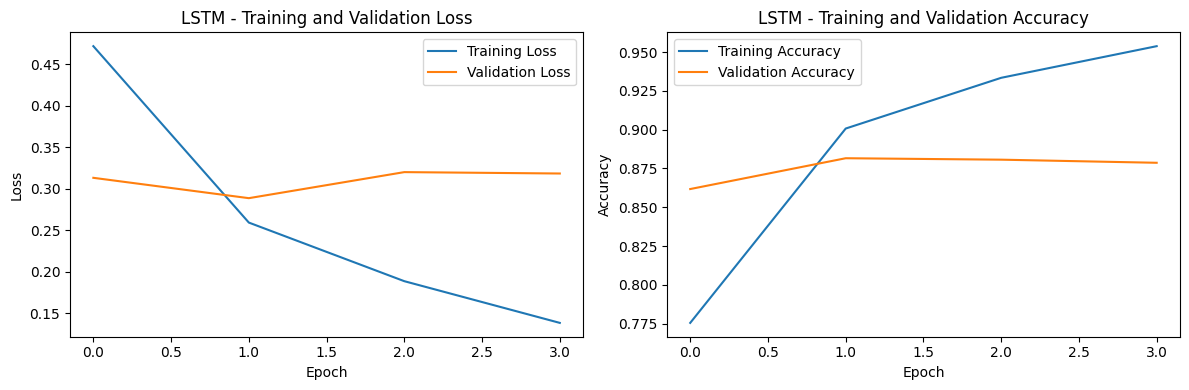

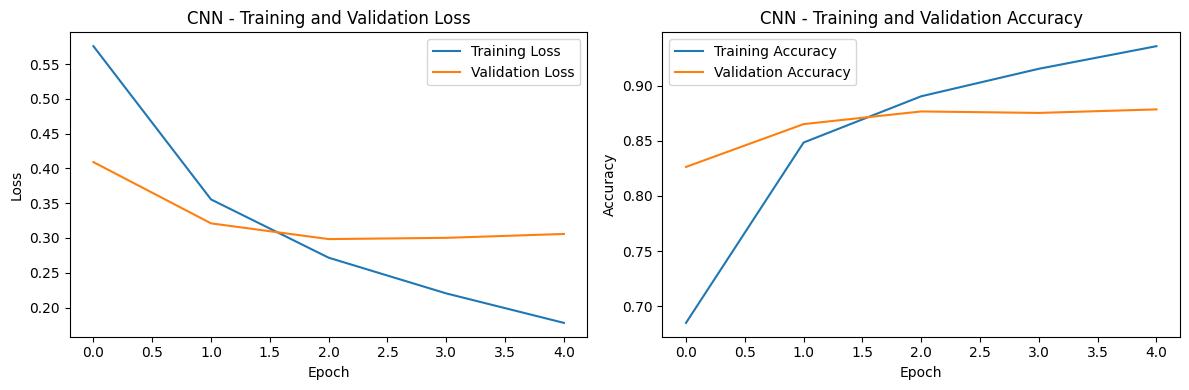

235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

LSTM Model Evaluation:
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87      3722
         1.0       0.88      0.88      0.88      3778

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500



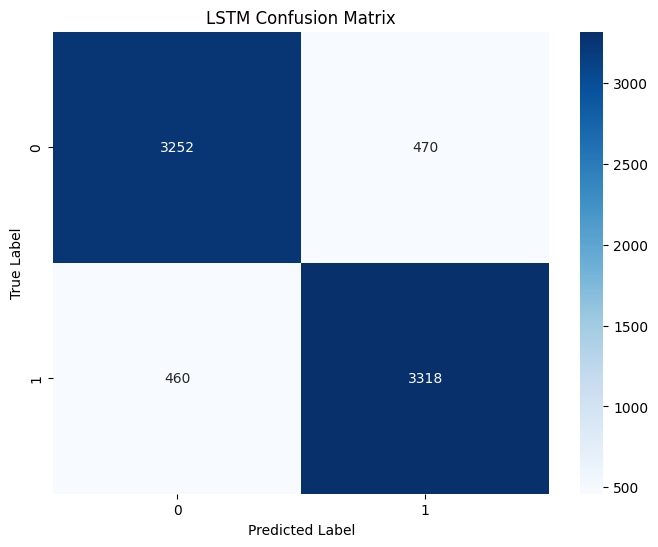


CNN Model Evaluation:
              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87      3722
         1.0       0.86      0.89      0.87      3778

    accuracy                           0.87      7500
   macro avg       0.87      0.87      0.87      7500
weighted avg       0.87      0.87      0.87      7500



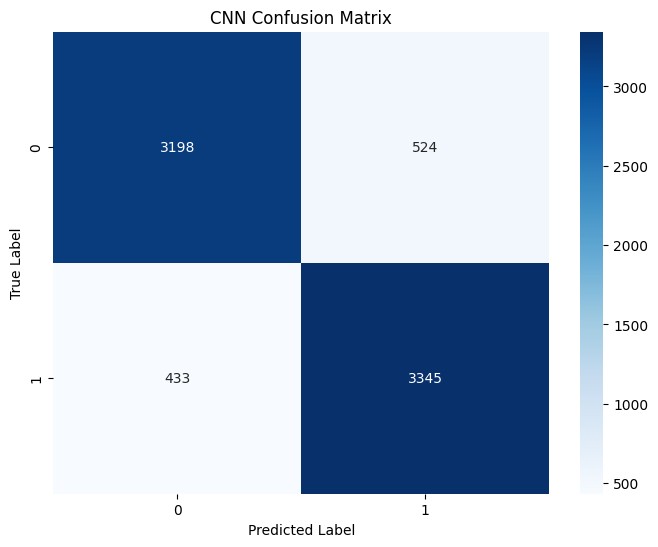


Best LSTM Hyperparameters:
embedding_dim: 256
lstm_units: 64
return_sequences: True
second_lstm: True
dropout: 0.4
learning_rate: 0.0034674567992975507
lstm_units_2: 16

Best CNN Hyperparameters:
embedding_dim: 32
filters: 96
kernel_size: 7
dropout: 0.30000000000000004
extra_dense: False
learning_rate: 0.0002973598687549219


In [32]:
# Retrain best LSTM model to get history
best_lstm_hparams = lstm_tuner.get_best_hyperparameters()[0]
best_lstm_model = build_lstm_model(best_lstm_hparams)
lstm_history = best_lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)]
)

# Retrain best CNN model to get history
best_cnn_hparams = cnn_tuner.get_best_hyperparameters()[0]
best_cnn_model = build_cnn_model(best_cnn_hparams)
cnn_history = best_cnn_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)]
)

# Evaluate models
lstm_results = best_lstm_model.evaluate(X_test_pad, y_test)
print("\nLSTM Model Results:")
print(f"Test Accuracy: {lstm_results[1]:.4f}")

cnn_results = best_cnn_model.evaluate(X_test_pad, y_test)
print("\nCNN Model Results:")
print(f"Test Accuracy: {cnn_results[1]:.4f}")

# Plot training history
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Plot training history for both models
plot_training_history(lstm_history, 'LSTM')
plot_training_history(cnn_history, 'CNN')

# Additional evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, (y_pred > 0.5).astype(int))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Get predictions
lstm_pred = best_lstm_model.predict(X_test_pad)
cnn_pred = best_cnn_model.predict(X_test_pad)

# Plot confusion matrices
print("\nLSTM Model Evaluation:")
print(classification_report(y_test, (lstm_pred > 0.5).astype(int)))
plot_confusion_matrix(y_test, lstm_pred, 'LSTM')

print("\nCNN Model Evaluation:")
print(classification_report(y_test, (cnn_pred > 0.5).astype(int)))
plot_confusion_matrix(y_test, cnn_pred, 'CNN')

# Print best hyperparameters
print("\nBest LSTM Hyperparameters:")
for param, value in best_lstm_hparams.values.items():
    print(f"{param}: {value}")

print("\nBest CNN Hyperparameters:")
for param, value in best_cnn_hparams.values.items():
    print(f"{param}: {value}")

# Summary of Sentiment Analysis Results - Conclusion

## Model Comparison
- **LSTM Model**: 87.60% accuracy, ~19 min training time
- **CNN Model**: 87.24% accuracy, ~5.6 min training time

## Key Takeaways
1. **Performance**:
   - Both models achieved similar accuracy (~87%)
   - Balanced performance across positive/negative classes
   - LSTM slightly better but 3.4x slower than CNN

2. **Best Architecture**:
   - LSTM: Two-layer (64→16 units), 256D embeddings, 0.4 dropout
   - CNN: Single layer (96 filters), kernel size 7, 32D embeddings, 0.3 dropout

3. **Practical Recommendations**:
   - For accuracy priority: Use LSTM
   - For speed priority: Use CNN
   - Both models suitable for production use

## Future Work
- Explore hybrid architectures
- Implement attention mechanisms
- Optimize training process